# Baseline Evaluation Notebook


## Setup


In [1]:
# Importing packages
from matplotlib.figure import Figure

import json
import torch
import mlflow
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [2]:
# Setting tracking uri to db
mlflow.set_tracking_uri("sqlite:///../mlflow.db")

In [ ]:
# Declaring fig save path
metrics_save_path = "../outputs/figures/baseline_metrics_comparison.png"
cf_save_path = "../outputs/figures/confusion_matrices_all_models.png"

### Functions


In [4]:
# Plot metrics
def plot_metrics(
    models: list[str], metrics: dict[str, list[float]], save_path: str
) -> Figure:
    """Plots accuracy, recall, precision and f1-score for a list of models.

    Args:
        models (list[str]): List of model names.
        metrics (dict[str, list[float]]): Dictionary with metrics for a given model.
        save_path (str): Save path for figure.

    Returns:
        Figure: Figure object.
    """

    x = np.arange(len(models))
    n_metrics = len(metrics)
    width = 0.8 / n_metrics

    fig, ax = plt.subplots(figsize=(10, 5))

    for i, (metric_name, values) in enumerate(metrics.items()):
        offset = (i - (n_metrics - 1) / 2) * width
        bars = ax.bar(x + offset, values, width, label=metric_name)
        ax.bar_label(bars, fmt="%.4f", padding=2, fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title("Baseline Model Comparison: Accuracy, F1, Precision, Recall")
    ax.legend(loc="lower right", ncols=4, fontsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

    return fig

In [5]:
def plot_confusion_matrices(
    evals: list[dict], class_names: list[str], save_path: str
) -> Figure:
    """Plots Confusion matrix of a list of models.

    Args:
        evals (list[dict]): List of dictionaries with model evaluations.
        class_names (list[str]): List of class names, with class # corresponding to index #.
        save_path (str): Save path for figure.

    Returns:
        Figure: Figure object.
    """
    n = len(evals)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, model in zip(axes, evals):
        y_true = np.round(model["targets"]).astype(int)
        y_pred = np.round(model["predictions"]).astype(int)

        cm = confusion_matrix(y_true, y_pred)
        cm_norm = cm / cm.sum(axis=1, keepdims=True)

        ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
        ax.set_title(model["model_name"], fontweight="bold")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=30, ha="right")
        ax.set_yticklabels(class_names)

        thresh = 0.5
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                ax.text(
                    j,
                    i,
                    f"{cm_norm[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                )

    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    return fig

## Loading eval JSON


In [6]:
# Getting evaluation for all models
with open("../outputs/eval_jsons/all_models_eval.json", "r") as file:
    evals = json.load(file)

## Loading MLflow runs


In [7]:
run_ids = {
    "544937e7677e4d3d982656ad11c6882c": "pn_encoder",
    "d245827411c0458db9efe82b14329b8b": "grouped_lead_cnn",
    "8f38dc123bb94dcbafeb7ce23293bbb6": "swin_transformer",
    "e6acee843bd5435db421b4d703705634": "cnn_bert",
}

In [8]:
# Loading all runs
runs = mlflow.search_runs(search_all_experiments=True)

runs = runs[runs["run_id"].isin(run_ids.keys())]
runs["model_name"] = run_ids.values()

In [9]:
metric_columns = [
    "metrics.train_acc",
    "metrics.test_acc",
    "metrics.test_f1",
    "metrics.test_precision",
    "metrics.test_recall",
    "metrics.train_loss",
    "metrics.test_loss",
]

metrics_df = runs[["model_name", *metric_columns]]

## Displaying Logged Metrics


In [10]:
metrics_df

,model_name,metrics.train_acc,metrics.test_acc,metrics.test_f1,metrics.test_precision,metrics.test_recall,metrics.train_loss,metrics.test_loss
0,pn_encoder,0.991682,0.915206,0.915193,0.915454,0.915200,0.023574,0.456278
1,grouped_lead_cnn,1.000000,0.987749,0.987747,0.988024,0.987768,0.000196,0.043222
2,swin_transformer,0.966271,0.768760,0.767974,0.772263,0.768672,0.104958,0.826258
4,cnn_bert,0.999233,0.949464,0.949464,0.949470,0.949462,0.007592,0.223780


## Querying live model


In [11]:
response = requests.get("http://127.0.0.1:8000/model/info", timeout=5)
response.json()

{'model_name': 'grouped_lead_cnn',
 'task': 'Chagas Classification with Grouped Lead CNN',
 'class_names': ['chagas', 'non-chagas'],
 'test_acc': 0.9877488514548239,
 'test_loss': 0.03011959899837772,
 'train_date': '20260623',
 'training_epochs': 40,
 'input_shape': [2609, 12, 734],
 'constructor_kwargs': {'feature_dim': 256,
  'num_heads': 4,
  'num_classes': 2,
  'ffn_dropout_p': 0.1,
  'clf_dropout_p': 0.3,
  'class_names': ['chagas', 'non-chagas']}}

## Visualisation


In [12]:
# Getting models and metrics
models = metrics_df["model_name"].tolist()
metrics = {
    "Accuracy": metrics_df["metrics.test_acc"].tolist(),
    "F1": metrics_df["metrics.test_f1"].tolist(),
    "Precision": metrics_df["metrics.test_precision"].tolist(),
    "Recall": metrics_df["metrics.test_recall"].tolist(),
}

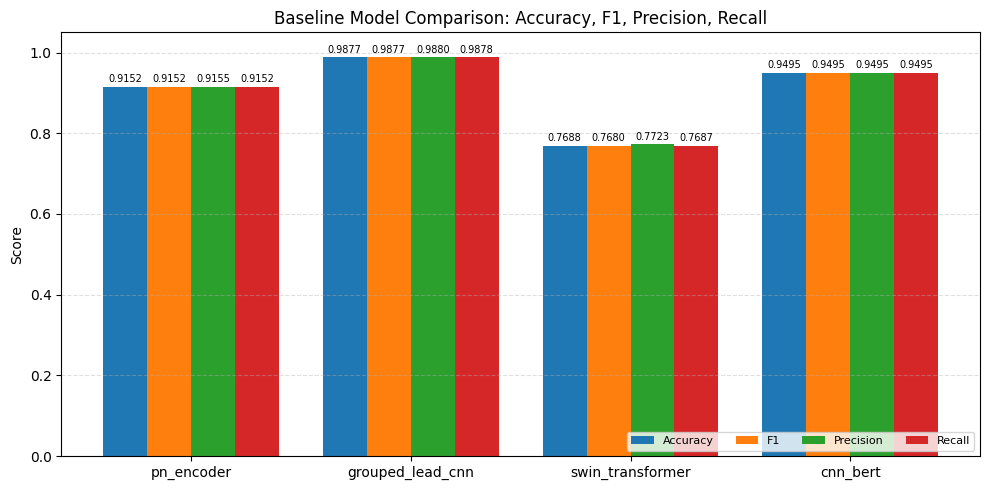

In [13]:
metrics_fig = plot_metrics(models=models, metrics=metrics, save_path=metrics_save_path)

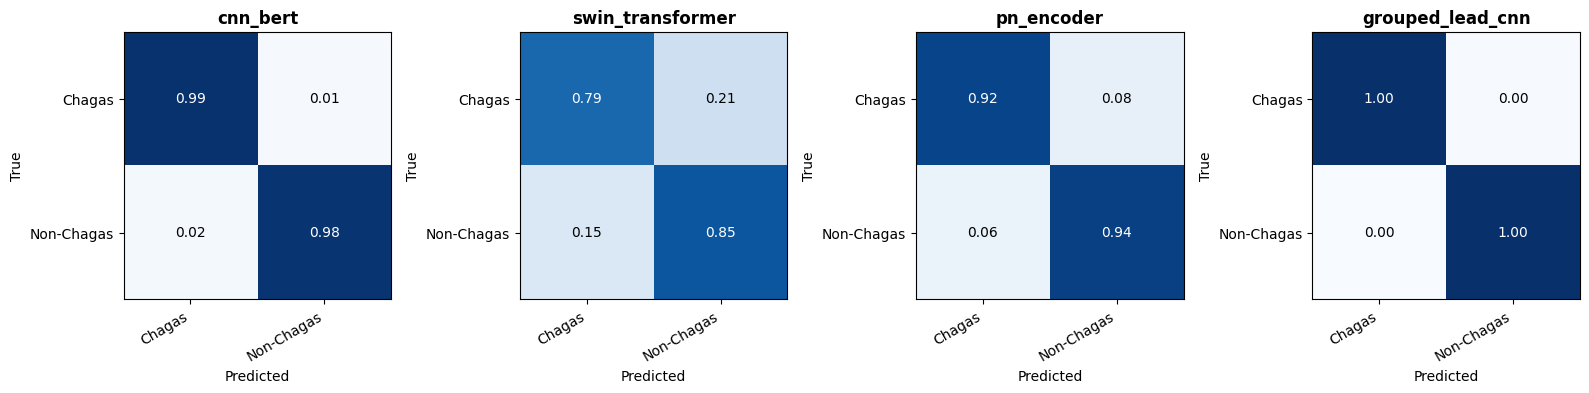

In [14]:
cf_fig = plot_confusion_matrices(
    evals=evals, class_names=["Chagas", "Non-Chagas"], save_path=cf_save_path
)